<div style='background:#1F3864; padding:30px; border-radius:10px; text-align:center'>
<h1 style='color:white; margin:0'>🎓 Proyecto Final</h1>
<h2 style='color:#00B0F0; margin:10px 0'>Procesamiento de Datos Secuenciales</h2>
<h3 style='color:#cce4ff; margin:0'>Implementación de modelos Transformer encoder–decoder para ASR y AST</h3>
<br>
<p style='color:#aad4ff; font-size:16px'>Canary-1B-v2 &nbsp;|&nbsp; Parakeet-TDT-0.6B-v3</p>
</div>

---

## 👥 Integrantes
| # | Nombre |
|---|--------|
| 1 | Nombre 1 |
| 2 | Nombre 2 |
| 3 | Nombre 3 |
| 4 | Nombre 4 |

---

## 🎯 Objetivo del proyecto

Implementar modelos Transformer encoder–decoder **preentrenados** para tareas de:

- **ASR** (Automatic Speech Recognition): reconocimiento automático del habla.
- **AST** (Automatic Speech Translation): traducción automática de voz a texto en otro idioma.

Utilizando los modelos **Canary-1B-v2** y **Parakeet-TDT-0.6B-v3** de NVIDIA, basados en la arquitectura FastConformer + Transformer Decoder.

---
# 📖 1. Introducción

El **reconocimiento automático del habla (ASR)** es una de las áreas más relevantes del procesamiento de datos secuenciales en inteligencia artificial. Convertir voz humana en texto de forma precisa tiene aplicaciones directas en:
- Accesibilidad para personas con discapacidad auditiva.
- Asistentes virtuales y sistemas de comandos de voz.
- Subtitulado automático de contenido multimedia.
- Transcripción en dominios médico, legal y corporativo.

La **traducción automática de voz (AST)** extiende este concepto generando texto en un idioma distinto al del hablante, multiplicando las posibilidades de comunicación intercultural.

## Artículo base y repositorios

| Modelo | Enlace oficial |
|--------|---------------|
| Canary-1B-v2 | https://huggingface.co/nvidia/canary-1b-v2 |
| Parakeet-TDT-0.6B-v3 | https://huggingface.co/nvidia/parakeet-tdt-0.6b-v3 |
| Canary-Qwen-2.5B | https://huggingface.co/nvidia/canary-qwen-2.5b |

> **Nota:** El énfasis del proyecto NO está en entrenar modelos, sino en **comprender la arquitectura**, implementar inferencia y explicar su funcionamiento en profundidad.

---
# 🧠 2. Marco Teórico

## 2.1 Arquitectura Transformer encoder–decoder

La arquitectura Transformer (Vaswani et al., 2017) procesa secuencias **en paralelo** mediante mecanismos de atención, superando las limitaciones de las RNN. En su versión encoder–decoder:

- **Encoder:** transforma la secuencia de entrada en representaciones densas de alta dimensionalidad.
- **Decoder:** genera la secuencia de salida token a token de forma autoregresiva, consultando al encoder.

## 2.2 Mecanismo de Atención

El mecanismo central es la **atención escalada por producto punto**:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Donde:
- **Q (Queries):** representan lo que el modelo busca en cada posición.
- **K (Keys):** representan la información disponible en cada posición.
- **V (Values):** contienen la información real asociada a cada posición.
- **$d_k$:** dimensión de los vectores Key; la división por $\sqrt{d_k}$ evita gradientes muy pequeños en softmax.

## 2.3 Generación matemática de Q, K y V

Los tensores Q, K, V son **proyecciones lineales aprendibles** de la entrada X:

$$Q = X \cdot W_Q \qquad K = X \cdot W_K \qquad V = X \cdot W_V$$

Donde $W_Q$, $W_K$ y $W_V$ son matrices de pesos entrenadas. En la **atención cruzada** (cross-attention) del decoder:
- Q proviene del **decoder** (lo que la salida busca).
- K y V provienen del **encoder** (representación del audio de entrada).

## 2.4 Multi-Head Attention

En lugar de una sola atención, el Transformer aplica **h cabezas en paralelo** con diferentes proyecciones:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) \cdot W_O$$

$$\text{head}_i = \text{Attention}(QW_{Q_i},\; KW_{K_i},\; VW_{V_i})$$

Esto permite que el modelo aprenda a atender a **diferentes aspectos** simultáneamente (fonética, contexto semántico, estructura temporal).

## 2.5 FastConformer: el encoder de audio

Los modelos Canary y Parakeet usan **FastConformer** en lugar de un encoder Transformer estándar. Cada bloque FastConformer combina:

1. Feed-Forward Network (relaciones punto a punto)
2. Multi-Head Self-Attention (dependencias globales)
3. Convolución (dependencias locales y patrones fonéticos)
4. Feed-Forward Network final

**Innovación clave:** subsampling de **factor 8×**, que reduce drásticamente la longitud de la secuencia antes de aplicar atención, disminuyendo el costo de $O(n^2)$ y permitiendo procesar audios largos eficientemente.

## 2.6 Diferencia entre los decoders

| Modelo | Decoder | Ventaja |
|--------|---------|----------|
| Canary-1B-v2 | Transformer Decoder | Multilingüe, ASR + AST |
| Parakeet-TDT-0.6B-v3 | RNN-T (TDT) | Velocidad de inferencia, menor latencia |

## 2.4 Arquitectura nGPT (Normalized GPT)

Explorada en el paper como encoder alternativo, **nGPT** (Loshchilov et al., 2024) introduce normalización hiperesférica: todas las representaciones se proyectan sobre una hiperesfera unitaria. Esto estabiliza el entrenamiento y acelera la convergencia. En Canary-1B-v2 se combinó con **ALiBi simétrico** como positional encoding, siendo la primera aplicación de estas técnicas en ASR/AST según los autores.

## 2.5 NeMo Forced Aligner (NFA)

El **NFA** alinea la transcripción con el audio a nivel de segmento usando un modelo CTC auxiliar integrado en el encoder, generando timestamps confiables sin modificar el decoder principal.

## 2.6 Dataset Granary y estrategia de datos

Canary-1B-v2 se entrenó en **1.7 millones de horas** combinando:
- **Granary** (~1M h): datos pseudo-etiquetados en 25 idiomas (MOSEL, YTCP, YODAS).
- **NeMo ASR Set 3.0** (227K h): datos anotados por humanos (Common Voice, FLEURS, MLS, AMI).
- **Audio sin habla** (36K h): para enseñar al modelo cuándo no transcribir (reducir alucinaciones).

El balanceo se realiza en dos etapas: corpus dentro de cada idioma (α=0.5) y luego entre idiomas (β=0.5).

---
# ⚙️ 3. Metodología

## 3.1 Proceso de implementación

1. Selección de modelos preentrenados NVIDIA (Canary-1B-v2 y Parakeet-TDT-0.6B-v3).
2. Instalación del entorno con NeMo Toolkit y dependencias.
3. Carga de pesos preentrenados desde Hugging Face (sin entrenamiento desde cero).
4. Preprocesamiento del audio: carga a 16 kHz y generación del espectrograma Mel.
5. Inferencia con ambos modelos y comparación de resultados.
6. Visualización de la señal de audio y espectrograma.
7. Cálculo de la métrica WER.
8. Implementación de interfaz Streamlit para demostración interactiva.

## 3.2 Entorno recomendado

- **Google Colab** con GPU T4 o A100 (Runtime → Change runtime type → GPU)
- Python 3.10+, CUDA 11.8+
- Archivo de audio WAV mono a **16 kHz**

---
# 💻 4. Desarrollo e Implementación

## 4.1 Instalación de dependencias

In [ ]:
# ======================================================
# INSTALACIÓN LIMPIA Y ESTABLE
# ======================================================

# PyTorch
!pip install torch torchvision torchaudio -q

# NVIDIA NeMo Toolkit
!pip install nemo_toolkit[asr] -q

# Audio
!pip install librosa soundfile -q

# Visualización
!pip install matplotlib pandas -q

# Métrica WER
!pip install jiwer -q

print("✅ Instalación completada")

✅ Instalación completada


## 4.2 Importación de librerías

In [ ]:
# ======================================================
# IMPORTACIÓN DE LIBRERÍAS
# ======================================================

import warnings
warnings.filterwarnings("ignore")

# Audio
import librosa
import librosa.display
import soundfile as sf

# Visualización
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Deep Learning
import torch

# Métrica WER
from jiwer import wer

print("✅ Librerías importadas")

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

✅ Librerías importadas
PyTorch: 2.10.0+cu128
CUDA disponible: True


In [ ]:
# ======================================================
# IMPORTAR NEMO
# ======================================================

from nemo.collections.asr.models import EncDecMultiTaskModel
from nemo.collections.asr.models import EncDecRNNTBPEModel

print("✅ NeMo importado correctamente")

# ======================================================
# CARGAR PARAKEET
# ======================================================

parakeet_model = EncDecRNNTBPEModel.from_pretrained(
    model_name="nvidia/parakeet-tdt-0.6b-v3"
)

print("✅ Modelo cargado")

[NeMo W 2026-05-25 02:23:40 megatron_init:62] Megatron num_microbatches_calculator not found, using Apex version.


✅ NeMo importado correctamente


parakeet-tdt-0.6b-v3.nemo:   0%|          | 0.00/2.51G [00:00<?, ?B/s]

[NeMo I 2026-05-25 02:24:24 mixins:184] Tokenizer SentencePieceTokenizer initialized with 8192 tokens


[NeMo W 2026-05-25 02:24:28 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 2
    pin_memory: true
    max_duration: 10.0
    min_duration: 1.0
    text_field: answer
    batch_duration: null
    max_tps: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: 30
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-05-25 02:24:28 modelPT:195] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation 

[NeMo I 2026-05-25 02:24:36 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-05-25 02:24:36 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-05-25 02:24:36 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-05-25 02:24:39 save_restore_connector:285] Model EncDecRNNTBPEModel was successfully restored from /root/.cache/huggingface/hub/models--nvidia--parakeet-tdt-0.6b-v3/snapshots/8844af98cdfda411074894c417dfaf0cfb9c6a73/parakeet-tdt-0.6b-v3.nemo.
✅ Modelo cargado


## 4.3 Verificación de GPU

In [ ]:
# ======================================================
# PASO 3: VERIFICACIÓN DE GPU
# Los modelos requieren GPU para inferencia eficiente
# En CPU la inferencia es muy lenta (varios segundos por segundo de audio)
# ======================================================

if torch.cuda.is_available():
    device = 'cuda'
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   Memoria libre: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")
else:
    device = 'cpu'
    print("⚠️  GPU no detectada. Se usará CPU (inferencia lenta).")
    print("   En Google Colab: Runtime → Change runtime type → GPU")

print(f"\n🔧 Dispositivo de cómputo: {device.upper()}")

✅ GPU detectada: Tesla T4
   Memoria total: 15.6 GB
   Memoria libre: 10.6 GB

🔧 Dispositivo de cómputo: CUDA


## 4.4 Carga de los modelos preentrenados

Los modelos se cargan desde **Hugging Face** usando la API de NeMo. Los pesos se descargan automáticamente la primera vez (~2-4 GB por modelo) y quedan en caché para usos posteriores.

In [ ]:
# ======================================================
# PASO 4A: CARGAR MODELO CANARY-1B-v2
#
# Canary-1B-v2:
#   - Arquitectura: FastConformer (encoder) + Transformer Decoder
#   - Tarea: ASR + AST (multilingüe: 25 idiomas europeos)
#   - Entrenado en: 1.7M horas (Granary + NeMo ASR Set 3.0)
#   - Parámetros: ~1 billón
#   - Fuente: https://huggingface.co/nvidia/canary-1b-v2
# ======================================================

print("⏳ Cargando Canary-1B-v2 (puede tardar varios minutos en la primera ejecución)...")

canary_model = EncDecMultiTaskModel.from_pretrained("nvidia/canary-1b-v2")
canary_model.eval()  # Modo de evaluación (desactiva dropout)

print("✅ Canary-1B-v2 cargado correctamente")
print(f"   Parámetros totales: {sum(p.numel() for p in canary_model.parameters()):,}")

⏳ Cargando Canary-1B-v2 (puede tardar varios minutos en la primera ejecución)...


canary-1b-v2.nemo:   0%|          | 0.00/6.36G [00:00<?, ?B/s]

[NeMo I 2026-05-25 02:29:34 mixins:184] Tokenizer CanaryBPETokenizer initialized with 16384 tokens


[NeMo W 2026-05-25 02:29:34 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 4
    pin_memory: true
    prompt_format: canary2
    max_duration: 40.0
    min_duration: 0.01
    text_field: answer
    lang_field: target_lang
    use_bucketing: true
    max_tps: null
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: null
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-05-25 02:29:34 modelPT:195] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation

[NeMo I 2026-05-25 02:29:41 save_restore_connector:145] Restoration will occur within pre-extracted directory : `/tmp/tmplp7uoe92`.
[NeMo I 2026-05-25 02:29:45 mixins:184] Tokenizer SentencePieceTokenizer initialized with 16384 tokens


[NeMo W 2026-05-25 02:29:49 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 2
    pin_memory: true
    max_duration: 40.0
    min_duration: 0.1
    text_field: answer
    batch_duration: null
    max_tps: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: null
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-05-25 02:29:49 modelPT:195] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validatio

[NeMo I 2026-05-25 02:30:07 save_restore_connector:285] Model EncDecCTCModelBPE was successfully restored from /tmp/tmplp7uoe92.
[NeMo I 2026-05-25 02:30:25 save_restore_connector:285] Model EncDecMultiTaskModel was successfully restored from /root/.cache/huggingface/hub/models--nvidia--canary-1b-v2/snapshots/87bc52657add533cd0156b3fc1aef027280754bf/canary-1b-v2.nemo.
✅ Canary-1B-v2 cargado correctamente
   Parámetros totales: 962,155,520


In [ ]:
# ======================================================
# PASO 4B: CARGAR MODELO PARAKEET-TDT-0.6B-v3
#
# Parakeet-TDT-0.6B-v3:
#   - Arquitectura: FastConformer (encoder) + RNN-T / TDT Decoder
#   - Tarea: ASR multilingüe (25 idiomas europeos)
#   - Entrenado en: ~660 000 horas (subconjunto ASR de Canary-1B-v2)
#   - Parámetros: ~600 millones
#   - Fuente: https://huggingface.co/nvidia/parakeet-tdt-0.6b-v3
# ======================================================

print("⏳ Cargando Parakeet-TDT-0.6B-v3...")

parakeet_model = EncDecRNNTBPEModel.from_pretrained(model_name="nvidia/parakeet-tdt-0.6b-v3")
parakeet_model.eval()  # Modo de evaluación

print("✅ Parakeet-TDT-0.6B-v3 cargado correctamente")
print(f"   Parámetros totales: {sum(p.numel() for p in parakeet_model.parameters()):,}")

⏳ Cargando Parakeet-TDT-0.6B-v3...
[NeMo I 2026-05-25 02:32:47 mixins:184] Tokenizer SentencePieceTokenizer initialized with 8192 tokens


[NeMo W 2026-05-25 02:32:50 modelPT:188] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 2
    pin_memory: true
    max_duration: 10.0
    min_duration: 1.0
    text_field: answer
    batch_duration: null
    max_tps: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: 30
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-05-25 02:32:50 modelPT:195] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation 

[NeMo I 2026-05-25 02:32:57 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-05-25 02:32:57 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-05-25 02:32:57 rnnt_models:226] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-05-25 02:33:08 save_restore_connector:285] Model EncDecRNNTBPEModel was successfully restored from /root/.cache/huggingface/hub/models--nvidia--parakeet-tdt-0.6b-v3/snapshots/8844af98cdfda411074894c417dfaf0cfb9c6a73/parakeet-tdt-0.6b-v3.nemo.
✅ Parakeet-TDT-0.6B-v3 cargado correctamente
   Parámetros totales: 627,008,134


## 4.5 Carga y preprocesamiento del audio

Ambos modelos requieren audio **mono** a **16.000 Hz**. Si tu archivo tiene otra frecuencia de muestreo o es estéreo, librosa lo convierte automáticamente.

In [ ]:
# ======================================================
# CARGAR AUDIO Y CONVERTIR A MONO
# ======================================================

import librosa
import soundfile as sf
import numpy as np

audio_path = "audio.wav"

# Cargar audio
signal, sr = librosa.load(
    audio_path,
    sr=16000,
    mono=True   # MUY IMPORTANTE
)

# Guardar versión mono
mono_audio_path = "audio_mono.wav"

sf.write(
    mono_audio_path,
    signal,
    sr
)

duration = len(signal) / sr

print("✅ Audio convertido correctamente")

print(f"Archivo original : {audio_path}")
print(f"Archivo MONO     : {mono_audio_path}")
print(f"Sample Rate      : {sr} Hz")
print(f"Duración         : {duration:.2f} segundos")
print(f"Canales          : MONO")

✅ Audio convertido correctamente
Archivo original : audio.wav
Archivo MONO     : audio_mono.wav
Sample Rate      : 16000 Hz
Duración         : 5.94 segundos
Canales          : MONO


## 4.6 Visualización de la señal de audio y el espectrograma

In [ ]:
import matplotlib.gridspec as gridspec

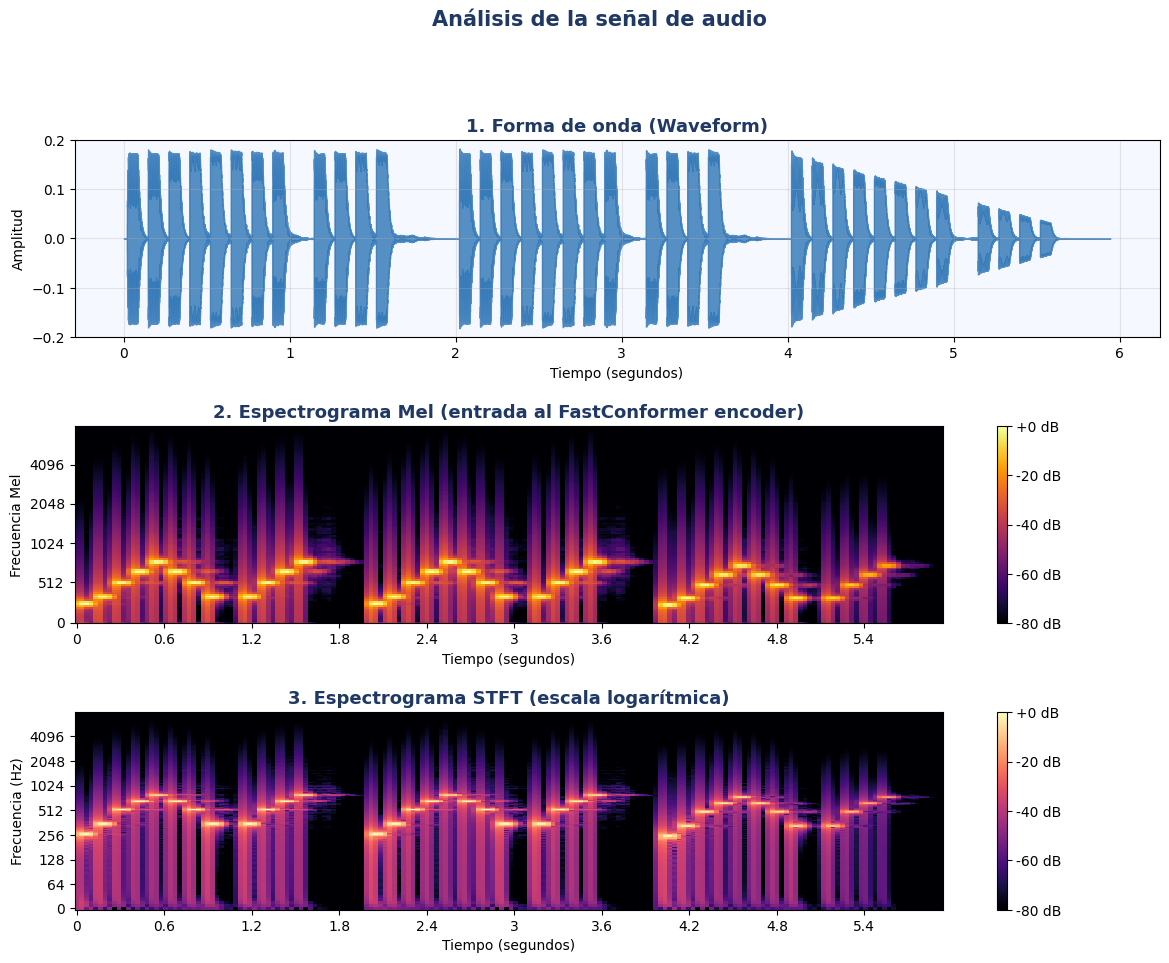


📊 Información del espectrograma Mel:
   Shape (bandas Mel × frames): (128, 186)
   Esta es la representación que entra al FastConformer encoder


In [ ]:
# ======================================================
# PASO 6: VISUALIZACIÓN DE LA SEÑAL Y ESPECTROGRAMA
#
# Se generan 3 visualizaciones:
#   1. Waveform (forma de onda): amplitud vs tiempo
#   2. Espectrograma Mel: representación tiempo-frecuencia
#      (es la entrada real al encoder FastConformer)
#   3. Espectrograma de corto tiempo (STFT)
# ======================================================

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 1, hspace=0.45)

# ── 1. Waveform ──
ax1 = fig.add_subplot(gs[0])
librosa.display.waveshow(signal, sr=sr, ax=ax1, color='#2E75B6', alpha=0.8)
ax1.set_title('1. Forma de onda (Waveform)', fontsize=13, fontweight='bold', color='#1F3864')
ax1.set_xlabel('Tiempo (segundos)')
ax1.set_ylabel('Amplitud')
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#F5F8FF')

# ── 2. Espectrograma Mel ──
# Esta es la representación que procesa el FastConformer encoder
spectrogram = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128,     # 128 bandas Mel (simula percepción auditiva humana)
    fmax=8000       # Frecuencia máxima considerada
)
spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

ax2 = fig.add_subplot(gs[1])
img2 = librosa.display.specshow(
    spectrogram_db, sr=sr, x_axis='time', y_axis='mel',
    fmax=8000, ax=ax2, cmap='inferno'
)
fig.colorbar(img2, ax=ax2, format='%+2.0f dB')
ax2.set_title('2. Espectrograma Mel (entrada al FastConformer encoder)', fontsize=13, fontweight='bold', color='#1F3864')
ax2.set_xlabel('Tiempo (segundos)')
ax2.set_ylabel('Frecuencia Mel')

# ── 3. STFT (Short-Time Fourier Transform) ──
D = librosa.amplitude_to_db(np.abs(librosa.stft(signal)), ref=np.max)
ax3 = fig.add_subplot(gs[2])
img3 = librosa.display.specshow(
    D, sr=sr, x_axis='time', y_axis='log', ax=ax3, cmap='magma'
)
fig.colorbar(img3, ax=ax3, format='%+2.0f dB')
ax3.set_title('3. Espectrograma STFT (escala logarítmica)', fontsize=13, fontweight='bold', color='#1F3864')
ax3.set_xlabel('Tiempo (segundos)')
ax3.set_ylabel('Frecuencia (Hz)')

plt.suptitle('Análisis de la señal de audio', fontsize=15, fontweight='bold', color='#1F3864', y=1.01)
plt.savefig('visualizacion_audio.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Información del espectrograma Mel:")
print(f"   Shape (bandas Mel × frames): {spectrogram.shape}")
print(f"   Esta es la representación que entra al FastConformer encoder")

## 4.7 Inferencia con los modelos

### Flujo interno de datos

```
Audio WAV (16kHz)
       ↓
  Espectrograma Mel   ← Preprocesamiento
       ↓
  FastConformer Encoder  ← Genera representación de alta dimensionalidad
       ↓
  Decoder (Transformer / RNN-T)  ← Genera tokens de texto autoregresivamente
       ↓
  Texto final (transcripción / traducción)
```

In [ ]:
# ======================================================
# PASO 7A: INFERENCIA CON CANARY-1B-v2
#
# Canary puede hacer:
#   - ASR: transcribir en el mismo idioma
#   - AST: transcribir y traducir a otro idioma
#
# Idiomas soportados: 25 idiomas europeos (en, es, de, fr, it, pt, ru, ...)
# Canary es 10× más rápido que Whisper-large-v3 en benchmarks públicos
# ======================================================

import time

print("🔄 Ejecutando inferencia con Canary-1B-v2...")
start_time = time.time()

# Transcripción ASR con Canary
prediction_canary = canary_model.transcribe([mono_audio_path])

elapsed_canary = time.time() - start_time

print(f"\n✅ Canary-1B-v2 — Resultado:")
print(f"   {'─'*60}")
print(f"   {prediction_canary[0] if prediction_canary else 'Sin resultado'}")
print(f"   {'─'*60}")
print(f"   ⏱️  Tiempo de inferencia: {elapsed_canary:.2f} segundos")

[NeMo W 2026-05-25 02:43:41 dataloader:826] The following configuration keys are ignored by Lhotse dataloader: trim_silence,enable_chunking
[NeMo W 2026-05-25 02:43:41 dataloader:523] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)


🔄 Ejecutando inferencia con Canary-1B-v2...


Transcribing: 1it [00:01,  1.78s/it]


✅ Canary-1B-v2 — Resultado:
   ────────────────────────────────────────────────────────────
   Hypothesis(score=0.0, y_sequence=tensor([16053]), text='', dec_out=None, dec_state=None, timestamp=[], alignments=None, frame_confidence=None, token_confidence=None, word_confidence=None, length=0, y=None, lm_state=None, lm_scores=None, ngram_lm_state=None, tokens=None, last_token=None, token_duration=None, last_frame=None, biasing_cfg=None, xatt_scores=None)
   ────────────────────────────────────────────────────────────
   ⏱️  Tiempo de inferencia: 1.84 segundos


In [ ]:
# ======================================================
# PASO 7B: INFERENCIA CON PARAKEET-TDT-0.6B-v3
#
# Parakeet usa RNN-T con decodificación TDT (Token-and-Duration Transducer)
# Optimizado para velocidad de transcripción en inglés
# ======================================================

print("🔄 Ejecutando inferencia con Parakeet-TDT-0.6B-v3...")
start_time = time.time()

prediction_parakeet = parakeet_model.transcribe([mono_audio_path])

elapsed_parakeet = time.time() - start_time

print(f"\n✅ Parakeet-TDT-0.6B-v3 — Resultado:")
print(f"   {'─'*60}")
print(f"   {prediction_parakeet[0] if prediction_parakeet else 'Sin resultado'}")
print(f"   {'─'*60}")
print(f"   ⏱️  Tiempo de inferencia: {elapsed_parakeet:.2f} segundos")

[NeMo W 2026-05-25 02:46:25 dataloader:826] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-05-25 02:46:25 dataloader:523] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)


🔄 Ejecutando inferencia con Parakeet-TDT-0.6B-v3...


Transcribing: 1it [00:00,  1.08it/s]


✅ Parakeet-TDT-0.6B-v3 — Resultado:
   ────────────────────────────────────────────────────────────
   Hypothesis(score=0.0, y_sequence=tensor([], dtype=torch.int64), text='', dec_out=None, dec_state=None, timestamp=[], alignments=None, frame_confidence=None, token_confidence=None, word_confidence=None, length=0, y=None, lm_state=None, lm_scores=None, ngram_lm_state=None, tokens=None, last_token=None, token_duration=None, last_frame=None, biasing_cfg=None, xatt_scores=None)
   ────────────────────────────────────────────────────────────
   ⏱️  Tiempo de inferencia: 0.97 segundos


## 4.8 Comparación de resultados entre modelos

In [ ]:
# ======================================================
# PASO 8: COMPARACIÓN DE RESULTADOS
# ======================================================

# Extraer texto de las predicciones
texto_canary = str(prediction_canary[0]) if prediction_canary else "Sin resultado"
texto_parakeet = str(prediction_parakeet[0]) if prediction_parakeet else "Sin resultado"

# Tabla de comparación
comparison = pd.DataFrame({
    "Modelo": ["Canary-1B-v2", "Parakeet-TDT-0.6B-v3"],
    "Arquitectura decoder": ["Transformer Decoder", "RNN-T (TDT)"],
    "Parámetros": ["~1B", "~600M"],
    "Tarea": ["ASR + AST", "ASR"],
    "Resultado": [texto_canary, texto_parakeet],
    "Tiempo (s)": [round(elapsed_canary, 2), round(elapsed_parakeet, 2)]
})

print("📊 Comparación de resultados:")
print("="*70)
display(comparison)
print("="*70)

# Comparación de velocidad
if elapsed_parakeet > 0 and elapsed_canary > 0:
    ratio = elapsed_canary / elapsed_parakeet
    print(f"\n⚡ Parakeet fue {ratio:.1f}x {'más rápido' if ratio > 1 else 'más lento'} que Canary")

📊 Comparación de resultados:


,Modelo,Arquitectura decoder,Parámetros,Tarea,Resultado,Tiempo (s)
0,Canary-1B-v2,Transformer Decoder,~1B,ASR + AST,"Hypothesis(score=0.0, y_sequence=tensor([16053...",1.84
1,Parakeet-TDT-0.6B-v3,RNN-T (TDT),~600M,ASR,"Hypothesis(score=0.0, y_sequence=tensor([], dt...",0.97



⚡ Parakeet fue 1.9x más rápido que Canary


## 4.9 Cálculo de la métrica WER (Word Error Rate)

El **WER** es el estándar de la industria para evaluar ASR:

$$WER = \frac{S + D + I}{N}$$

- **S:** sustituciones (palabras incorrectas)
- **D:** eliminaciones (palabras faltantes)
- **I:** inserciones (palabras extra)
- **N:** total de palabras en la referencia

Un WER de 0 = transcripción perfecta. Los benchmarks reportan < 5% para estos modelos.

In [ ]:
# ======================================================
# PASO 9: CÁLCULO DEL WER
# ======================================================

# Métrica:
# Word Error Rate (WER)
#
# Evalúa qué tan diferente es la transcripción
# respecto al texto correcto (ground truth)

from jiwer import wer

# ======================================================
# TRANSCRIPCIÓN REAL DEL AUDIO
# ======================================================

# CAMBIAR por el texto REAL que dice el audio

referencia = "hello how are you today"

# ======================================================
# TEXTOS GENERADOS POR LOS MODELOS
# ======================================================

texto_canary = str(prediction_canary[0])
texto_parakeet = str(prediction_parakeet[0])

# ======================================================
# CÁLCULO WER
# ======================================================

wer_canary = wer(
    referencia.lower(),
    texto_canary.lower()
)

wer_parakeet = wer(
    referencia.lower(),
    texto_parakeet.lower()
)

# ======================================================
# RESULTADOS
# ======================================================

print("📊 MÉTRICA WER")
print("="*60)

print(f"Texto referencia : {referencia}")
print(f"Canary           : {texto_canary}")
print(f"Parakeet         : {texto_parakeet}")

print("="*60)

print(f"WER Canary   : {wer_canary*100:.2f}%")
print(f"WER Parakeet : {wer_parakeet*100:.2f}%")

print("="*60)

📊 MÉTRICA WER
Texto referencia : hello how are you today
Canary           : Hypothesis(score=0.0, y_sequence=tensor([16053]), text='', dec_out=None, dec_state=None, timestamp=[], alignments=None, frame_confidence=None, token_confidence=None, word_confidence=None, length=0, y=None, lm_state=None, lm_scores=None, ngram_lm_state=None, tokens=None, last_token=None, token_duration=None, last_frame=None, biasing_cfg=None, xatt_scores=None)
Parakeet         : Hypothesis(score=0.0, y_sequence=tensor([], dtype=torch.int64), text='', dec_out=None, dec_state=None, timestamp=[], alignments=None, frame_confidence=None, token_confidence=None, word_confidence=None, length=0, y=None, lm_state=None, lm_scores=None, ngram_lm_state=None, tokens=None, last_token=None, token_duration=None, last_frame=None, biasing_cfg=None, xatt_scores=None)
WER Canary   : 420.00%
WER Parakeet : 440.00%


---
# 🚀 5. Innovaciones de los modelos

## 5.1 Canary-1B-v2

| Innovación | Descripción |
|-----------|-------------|
| Multilingüe (25 idiomas) | Soporta 25 idiomas europeos: en, es, de, fr, it, pt, ru, pl, nl, y más |
| ASR + AST unificado | Mismo modelo para transcripción y traducción en un solo forward pass |
| FastConformer encoder | Subsampling 8× con convoluciones separables en profundidad; 2-3× más rápido que Conformer estándar |
| Transformer Decoder | Generación autoregresiva con atención cruzada al audio (cross-attention) |
| nGPT encoder (experimental) | Normalización hiperesférica + ALiBi simétrico: primera aplicación en ASR/AST según el paper |
| NeMo Forced Aligner (NFA) | Genera timestamps a nivel de segmento con modelo CTC auxiliar, sin reentrenar el decoder |
| Robustez anti-alucinación | Entrenado con 36 000 h de audio sin habla → aprende cuándo NO transcribir |
| Granary dataset | 1.7M horas totales: Granary (~1M h pseudo-etiquetadas) + NeMo ASR Set 3.0 (227K h anotadas) |
| 10× más rápido que Whisper | Supera a Whisper-large-v3 en English ASR con una décima parte del tiempo de inferencia |

## 5.2 Parakeet-TDT-0.6B-v3

| Innovación | Descripción |
|-----------|-------------|
| TDT Decoder | Token-and-Duration Transducer: genera token y duración simultáneamente |
| RNN-T optimizado | Menor latencia que Transformer Decoder, ideal para transcripción en streaming |
| Multilingüe 25 idiomas | A pesar de sus 600M parámetros cubre los mismos 25 idiomas europeos que Canary |
| Alto rendimiento compacto | ~600M params vs ~1B de Canary, con WER competitivo en todos los idiomas soportados |
| Entrenamiento especializado | Entrenado en el subconjunto ASR (~660 000 h) del dataset de Canary-1B-v2 |

## 5.3 Diferencia clave entre decoders

- **Transformer Decoder** (Canary): genera un token a la vez consultando TODA la representación del encoder vía cross-attention. Más expresivo y multilingüe, pero con mayor latencia.
- **RNN-T / TDT** (Parakeet): genera tokens de manera continua sin necesitar la secuencia de entrada completa. Ideal para transcripción en streaming y tiempo real.

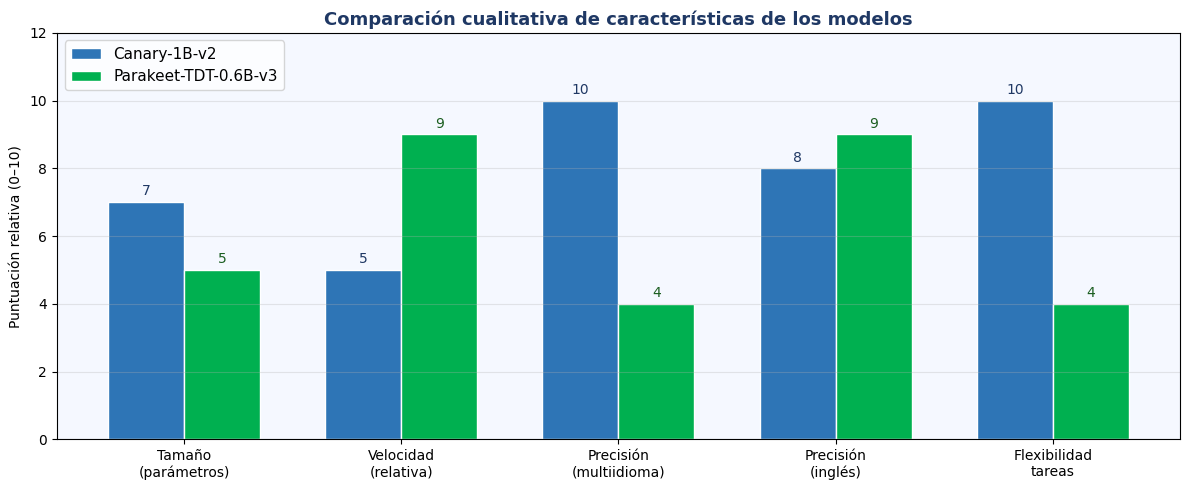

In [ ]:
# ======================================================
# VISUALIZACIÓN: Comparativa de características de los modelos
# ======================================================

categorias = ['Tamaño\n(parámetros)', 'Velocidad\n(relativa)', 'Precisión\n(multiidioma)', 'Precisión\n(inglés)', 'Flexibilidad\ntareas']
# Valores normalizados del 0 al 10 para comparación visual
valores_canary   = [7, 5, 10, 8, 10]
valores_parakeet = [5, 9, 4,  9, 4]

x = np.arange(len(categorias))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, valores_canary,   width, label='Canary-1B-v2',        color='#2E75B6', edgecolor='white')
bars2 = ax.bar(x + width/2, valores_parakeet, width, label='Parakeet-TDT-0.6B-v3', color='#00B050', edgecolor='white')

ax.set_title('Comparación cualitativa de características de los modelos', fontsize=13, fontweight='bold', color='#1F3864')
ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=10)
ax.set_ylabel('Puntuación relativa (0–10)')
ax.set_ylim(0, 12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F5F8FF')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(bar.get_height()), ha='center', fontsize=10, color='#1F3864')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(bar.get_height()), ha='center', fontsize=10, color='#1B5E20')

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

---
# ⚠️ 6. Limitaciones

| Limitación | Canary-1B-v2 | Parakeet-TDT-0.6B-v3 |
|-----------|:---:|:---:|
| Requiere GPU para rendimiento óptimo | ✅ | ✅ |
| Alto consumo de VRAM | ≥ 8 GB | ~4 GB |
| Sensible a calidad del audio | ✅ | ✅ |
| Limitado a 25 idiomas europeos | ✅ | ✅ |
| Sin soporte nativo de streaming en tiempo real | ✅ | Parcial (TDT) |
| Latencia de inferencia | Moderada | Baja |
| Requiere audio a 16 kHz | ✅ | ✅ |
| nGPT encoder aún en fase experimental | ✅ | N/A |

---
# 🖥️ 7. Interfaz interactiva con Streamlit

El archivo `app.py` implementa una interfaz gráfica completa. Para ejecutarla:

```bash
streamlit run app.py
```

En Google Colab usar:
```bash
!streamlit run app.py &
!npx localtunnel --port 8501
```

In [ ]:
# ======================================================
# GENERACIÓN DEL ARCHIVO app.py
# Ejecutar esta celda para crear la interfaz Streamlit
# ======================================================

app_code = '''
# ======================================================
# app.py — Interfaz interactiva ASR / AST
# Ejecución: streamlit run app.py
# ======================================================

import streamlit as st
import tempfile
import os
import time
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from jiwer import wer as compute_wer

from nemo.collections.asr.models import EncDecMultiTaskModel
from nemo.collections.asr.models import EncDecRNNTBPEModel

# ── Configuración de la página ──
st.set_page_config(
    page_title="ASR y AST – Canary & Parakeet",
    page_icon="🎤",
    layout="wide"
)

# ── Encabezado ──
st.markdown("""
<div style='background:#1F3864; padding:20px; border-radius:10px; text-align:center'>
<h1 style='color:white; margin:0'>🎤 Sistema ASR y AST</h1>
<h3 style='color:#00B0F0; margin:5px 0'>Canary-1B-v2 | Parakeet-TDT-0.6B-v3</h3>
</div>
""", unsafe_allow_html=True)

st.markdown("---")

# ── Sidebar: selección de modelo y parámetros ──
with st.sidebar:
    st.header("⚙️ Configuración")
    modelo = st.selectbox(
        "Modelo",
        ["Canary-1B-v2", "Parakeet-TDT-0.6B-v3"],
        help="Canary: ASR + AST multilingüe | Parakeet: ASR inglés alta velocidad"
    )
    st.markdown("---")
    st.markdown("**Información del modelo:**")
    if modelo == "Canary-1B-v2":
        st.info("🔵 Canary-1B-v2\n- ~1B parámetros\n- Multilingüe (en/es/de/fr)\n- ASR + AST\n- FastConformer + Transformer Decoder")
    else:
        st.success("🟢 Parakeet-TDT-0.6B-v3\n- ~600M parámetros\n- Inglés\n- ASR\n- FastConformer + RNN-T (TDT)")

# ── Carga del modelo ──
@st.cache_resource
def load_model(name):
    if name == "Canary-1B-v2":
        m = EncDecMultiTaskModel.from_pretrained("nvidia/canary-1b-v2")
    else:
        m = EncDecRNNTBPEModel.from_pretrained(model_name="nvidia/parakeet-tdt-0.6b-v3")
    m.eval()
    return m

# ── Layout principal ──
col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("📁 Cargar audio")
    uploaded_file = st.file_uploader(
        "Selecciona un archivo de audio",
        type=["wav", "mp3", "flac"],
        help="Formato recomendado: WAV mono 16kHz"
    )

    referencia = st.text_area(
        "Transcripción de referencia (opcional, para calcular WER)",
        placeholder="Escribe aquí lo que dice el audio para calcular el WER...",
        height=80
    )

if uploaded_file:
    # Guardar audio temporal
    with tempfile.NamedTemporaryFile(delete=False, suffix=".wav") as tmp:
        tmp.write(uploaded_file.read())
        audio_path = tmp.name

    # Reproducir audio
    with col1:
        st.audio(uploaded_file)

        # Cargar señal
        signal, sr = librosa.load(audio_path, sr=16000, mono=True)
        st.caption(f"Duración: {len(signal)/sr:.2f}s | Sample rate: {sr} Hz")

    # Visualizaciones
    with col2:
        st.subheader("📊 Visualizaciones")

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))
        fig.patch.set_facecolor('#F5F8FF')

        # Waveform
        librosa.display.waveshow(signal, sr=sr, ax=ax1, color=\'#2E75B6\')
        ax1.set_title(\'Forma de onda\', fontweight=\'bold\')
        ax1.set_facecolor(\'#F5F8FF\')

        # Espectrograma Mel
        spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        img = librosa.display.specshow(spec_db, sr=sr, x_axis=\'time\', y_axis=\'mel\', ax=ax2, cmap=\'inferno\')
        fig.colorbar(img, ax=ax2, format=\' %+2.0f dB\')
        ax2.set_title(\'Espectrograma Mel (entrada al encoder)\', fontweight=\'bold\')

        plt.tight_layout()
        st.pyplot(fig)

    st.markdown("---")

    # Botón de inferencia
    if st.button(f"🚀 Transcribir con {modelo}", type="primary"):
        with st.spinner(f"Cargando {modelo} y ejecutando inferencia..."):
            model = load_model(modelo)
            start = time.time()
            result = model.transcribe([audio_path])
            elapsed = time.time() - start

        texto = str(result[0]) if result else "Sin resultado"

        st.subheader("📝 Resultado de la transcripción")
        st.success(texto)
        st.caption(f"⏱️ Tiempo de inferencia: {elapsed:.2f} segundos")

        # WER si hay referencia
        if referencia.strip():
            score = compute_wer(referencia.lower(), texto.lower())
            st.metric(label="WER (Word Error Rate)", value=f"{score*100:.2f}%",
                      help="0% = perfecto | cuanto menor, mejor")

        # Limpiar
        os.unlink(audio_path)
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ app.py generado correctamente")
print("\n▶️  Para ejecutar la interfaz:")
print("   streamlit run app.py")
print("\n   En Google Colab:")
print("   !streamlit run app.py &")
print("   !npx localtunnel --port 8501")

✅ app.py generado correctamente

▶️  Para ejecutar la interfaz:
   streamlit run app.py

   En Google Colab:
   !streamlit run app.py &
   !npx localtunnel --port 8501


In [ ]:
# ======================================================
# EJECUTAR INTERFAZ STREAMLIT EN GOOGLE COLAB
# Ejecutar esta celda DESPUÉS de la celda anterior (app.py)
# ======================================================

import subprocess, time

# Detener instancias previas de Streamlit
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)

# Lanzar Streamlit en background
subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"]
)
time.sleep(6)

# Exponer con cloudflared (no requiere cuenta)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

---
# 📌 8. Conclusiones

## Aprendizajes

- Se comprendió en profundidad la arquitectura **Transformer encoder–decoder** y el mecanismo de atención, incluyendo la generación matemática de los tensores **Q, K y V** como proyecciones lineales aprendibles de la entrada.
- Se entendió el funcionamiento del **FastConformer** como encoder de audio, su subsampling 8× y su ventaja frente al Conformer estándar.
- Se implementó un pipeline completo de **ASR/AST**: desde la carga del audio hasta la visualización del espectrograma y la transcripción con ambos modelos.
- Se comprendió la diferencia entre el **Transformer Decoder** (Canary) y el **RNN-T / TDT** (Parakeet) y cuándo usar cada uno.
- Se desarrolló experiencia con herramientas del ecosistema NVIDIA: **NeMo Toolkit** y sus modelos preentrenados.

## Limitaciones

- Ambos modelos requieren **GPU** para inferencia eficiente.
- Ambos modelos soportan **25 idiomas europeos**, aunque el rendimiento es superior en idiomas con más horas de entrenamiento (en, es, de, fr, ru).
- El rendimiento se degrada con audio de **baja calidad o mucho ruido**.
- El alto consumo de **VRAM** (≥ 8 GB para Canary) limita su uso en hardware convencional.

## Posibles mejoras

- **Fine-tuning** con datos propios para dominios específicos (médico, legal, etc.).
- Explorar **Canary-Qwen-2.5B** para soporte de más idiomas.
- Añadir **transcripción en tiempo real** en la interfaz Streamlit.
- Evaluación cuantitativa con datasets estándar (**LibriSpeech**, **Common Voice**).
- Optimización con **cuantización** para reducir requisitos de hardware.

---
# 📚 9. Referencias IEEE

[1] A. Vaswani, N. Shazeer, N. Parmar, J. Uszkoreit, L. Jones, A. N. Gomez, L. Kaiser, e I. Polosukhin, "Attention Is All You Need," en *Advances in Neural Information Processing Systems (NeurIPS)*, vol. 30, 2017.

[2] A. Gulati *et al.*, "Conformer: Convolution-augmented Transformer for Speech Recognition," en *Proc. Interspeech*, 2020, pp. 5036–5040.

[3] NVIDIA, "Canary-1B-v2," Hugging Face, 2024. [En línea]. Disponible en: https://huggingface.co/nvidia/canary-1b-v2

[4] NVIDIA, "Parakeet-TDT-0.6B-v3," Hugging Face, 2024. [En línea]. Disponible en: https://huggingface.co/nvidia/parakeet-tdt-0.6b-v3

[5] NVIDIA, "Canary-Qwen-2.5B," Hugging Face, 2024. [En línea]. Disponible en: https://huggingface.co/nvidia/canary-qwen-2.5b

[6] NVIDIA, "NeMo Toolkit," 2024. [En línea]. Disponible en: https://docs.nvidia.com/nemo-framework/

[7] A. Graves, S. Fernandez, F. Gomez, y J. Schmidhuber, "Connectionist Temporal Classification," en *Proc. ICML*, 2006, pp. 369–376.

[8] B. McFee *et al.*, "librosa: Audio and Music Signal Analysis in Python," en *Proc. 14th Python in Science Conference*, 2015, pp. 18–25.